Binaire OK


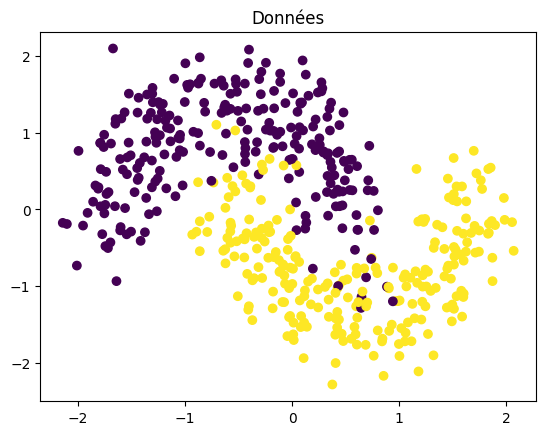

In [1]:

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

X, y = make_moons(n_samples=500, noise=0.2)
X = StandardScaler().fit_transform(X)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32).view(-1, 1)

model = nn.Sequential(
    nn.Linear(2, 16), nn.ReLU(),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1), nn.Sigmoid()
    )

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()

print("Binaire OK")
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("DonnÃ©es")
plt.show()

##### 1. Observer la loss:
La loss diminue progressivement, ce qui montre que le modÃ¨le apprend Ã  distinguer les deux classes.
Cependant, la convergence est lÃ©gÃ¨rement plus lente que pour la rÃ©gression, car les donnÃ©es sont plus complexes et non linÃ©airement sÃ©parables.

Epoch 0, Loss: 0.16969360411167145
Epoch 10, Loss: 0.14613956212997437
Epoch 20, Loss: 0.13070906698703766
Epoch 30, Loss: 0.12295948714017868
Epoch 40, Loss: 0.1192229762673378
Epoch 50, Loss: 0.11749356240034103
Epoch 60, Loss: 0.11657214909791946
Epoch 70, Loss: 0.11590928584337234
Epoch 80, Loss: 0.11532744020223618
Epoch 90, Loss: 0.1148604154586792


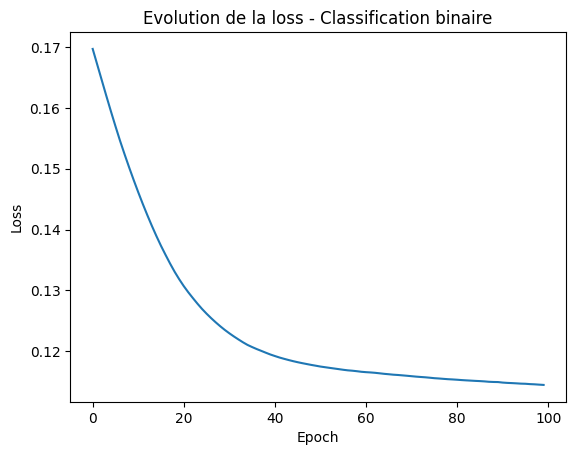

In [2]:
losses = []

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")
import matplotlib.pyplot as plt

plt.plot(losses)
plt.title("Evolution de la loss - Classification binaire")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

##### 2. Comparaison des performances :
RÃ©gression
La loss (MSE) diminue progressivement
Le modÃ¨le approxime correctement la relation linÃ©aire
Convergence stable et rapide

---->Bonne performance globale

Classification binaire
La loss (BCE) diminue mais plus lentement
Le modÃ¨le apprend une frontiÃ¨re non linÃ©aire
Convergence moins rapide

---->Performance correcte mais problÃ¨me plus difficile

Classification multi-classe
La loss (CrossEntropy) diminue rapidement
Le modÃ¨le sÃ©pare bien les diffÃ©rentes classes
Convergence rapide et stable

---->TrÃ¨s bonne performance

##### 3. Tester d'autres activations:


Binaire OK


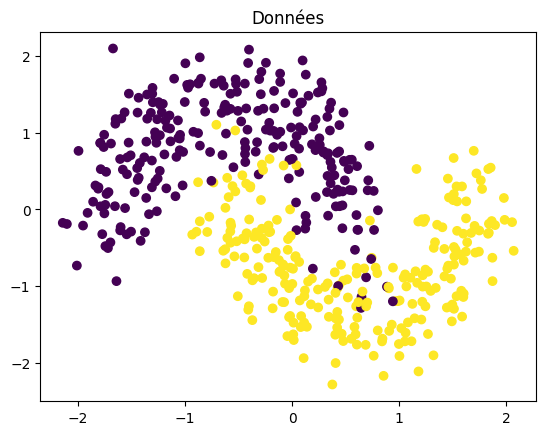

100


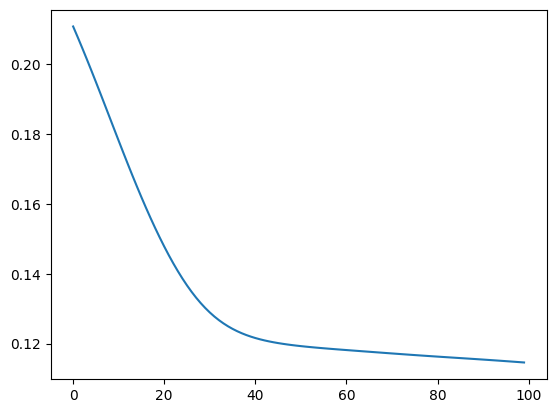

In [3]:
model = nn.Sequential(
    nn.Linear(2, 16), nn.Tanh(),
    nn.Linear(16, 8), nn.Tanh(),
    nn.Linear(8, 1), nn.Sigmoid()
    )

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()

print("Binaire OK")
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("DonnÃ©es")
plt.show()

losses = []
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(len(losses))  
plt.plot(losses)
plt.show()

Binaire OK


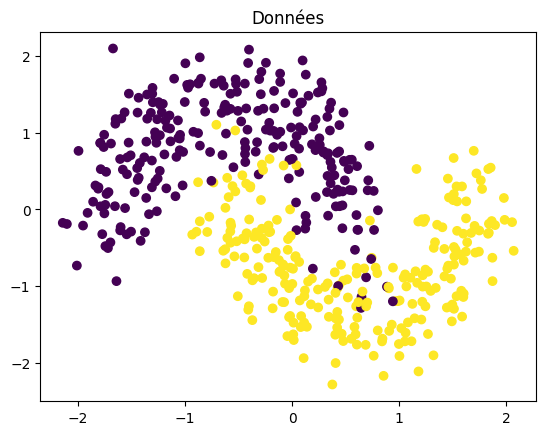

100


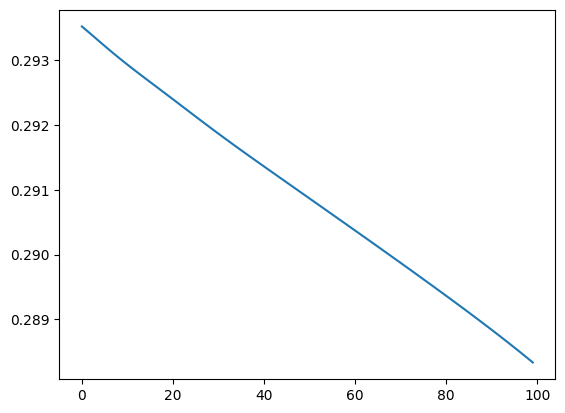

In [4]:
model = nn.Sequential(
    nn.Linear(2, 16), nn.Sigmoid(),
    nn.Linear(16, 8), nn.Sigmoid(),
    nn.Linear(8, 1), nn.Sigmoid()
)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    loss = criterion(model(X), y)
    loss.backward()
    optimizer.step()

print("Binaire OK")
plt.scatter(X[:,0], X[:,1], c=y)
plt.title("DonnÃ©es")
plt.show()


losses = []
for epoch in range(100):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
print(len(losses))  
plt.plot(losses)
plt.show()

Avec ReLU, la convergence est rapide et stable.
Avec Tanh, lâ€™apprentissage fonctionne mais est lÃ©gÃ¨rement plus lent.
Avec Sigmoid, la convergence est plus lente et peut Ãªtre instable Ã  cause du phÃ©nomÃ¨ne de saturation.

En conclusion: ReLU est la meilleure activation pour les couches cachÃ©es dans ce cas.

##### 4. Modifier le learning rate:


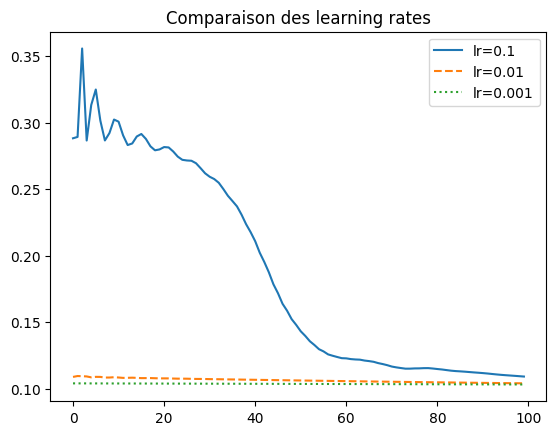

In [5]:
losses_lr1 = []

optimizer = optim.Adam(model.parameters(), lr=0.1)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()

    losses_lr1.append(loss.item())

losses_lr2 = []

optimizer = optim.Adam(model.parameters(), lr=0.01)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()

    losses_lr2.append(loss.item())

losses_lr3 = []

optimizer = optim.Adam(model.parameters(), lr=0.001)

for epoch in range(100):
    optimizer.zero_grad()
    
    y_pred = model(X)
    loss = criterion(y_pred, y)
    
    loss.backward()
    optimizer.step()
    losses_lr3.append(loss.item())

import matplotlib.pyplot as plt

plt.plot(losses_lr1, label="lr=0.1")
plt.plot(losses_lr2, '--', label="lr=0.01")  # pointillÃƒÂ©
plt.plot(losses_lr3, ':', label="lr=0.001")  # pointillÃƒÂ© diffÃƒÂ©rent
plt.legend()
plt.title("Comparaison des learning rates")
plt.show()

- La courbe lr=0.1 chute rapidement au debut, mais un pas aussi grand peut rendre l'apprentissage moins stable.
- La courbe lr=0.01 donne en general le meilleur compromis : baisse rapide de la loss avec une convergence plus reguliere.
- La courbe lr=0.001 est plus douce et stable, mais la convergence est plus lente sur 100 epochs.
- Conclusion: pour cette classification binaire, lr=0.01 semble le choix le plus equilibre entre vitesse et stabilite.